# Lab 24 — Topology and Geometry of Language Representations

[Open this notebook in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-24-topology-geometry-language.ipynb)

This lab accompanies **Chapter 24: Topology and Geometry of Language Representations** in *The Mathematics of Natural Language Processing*.

Previous labs studied language through tokens, probability distributions, vector spaces, neural networks, attention, transformers, retrieval, graphs, and optimization. This lab asks a different question:

> Once language objects are embedded as vectors, what is the **shape** of the representation space?

In this notebook, a set of words, sentences, documents, or prompts becomes a finite point cloud. We will study that point cloud with distances, neighborhood graphs, simplicial complexes, Betti numbers, persistent homology, local dimension, and simple Mapper-style summaries.

The goal is not to make topology mysterious. The goal is to make it computational and interpretable.

## Learning goals

By the end of this lab, you should be able to:

1. Treat a set of text embeddings as a finite metric space.
2. Compute Euclidean and cosine distance matrices.
3. Build neighborhood graphs at different distance thresholds.
4. Compute connected components using union-find.
5. Construct Vietoris--Rips complexes up to triangles.
6. Compute Betti numbers $beta_0$ and $beta_1$ from boundary matrices over $F_2$.
7. Interpret persistent connected components and simple one-dimensional loops.
8. Estimate local intrinsic dimension from neighborhoods.
9. Build a small Mapper-style summary of sentence embeddings.
10. Use topology as a representation diagnostic without overclaiming semantic meaning.

This notebook is designed for independent study. Read the text before running each code cell.

## 1. Mathematical background: point clouds from language

Suppose we have language objects

$$
t_1,t_2,\ldots,t_n.
$$

These may be words, tokens, sentences, documents, questions, answers, or retrieved chunks. An embedding model maps each object to a vector:

$$
f(t_i)=x_i \in R^d.
$$

The matrix

$$
X = \begin{bmatrix}x_1^T \\ x_2^T \\ \cdots \\ x_n^T\end{bmatrix} \in R^{n\times d}
$$

is a point cloud. Geometry studies distances, angles, norms, directions, and dimension. Topology studies qualitative shape: connected components, loops, voids, branching structure, and how these features change across scales.

A key object is the pairwise distance matrix

$$
D_{ij}=d(x_i,x_j).
$$

Two common choices are Euclidean distance

$$
d_E(x_i,x_j)=\|x_i-x_j\|_2
$$

and cosine distance

$$
d_C(x_i,x_j)=1-\frac{x_i^T x_j}{\|x_i\|_2\|x_j\|_2}.
$$

In NLP, cosine distance is often more meaningful when vector magnitude is not meant to carry semantic information.

## 2. Setup

We will use only NumPy, Pandas, and Matplotlib. We will implement the topological computations ourselves for small examples. This is not meant to replace professional TDA libraries; it is meant to reveal the mathematics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7243)

print("Libraries loaded.")

Libraries loaded.


## 3. Helper functions

The following functions compute distances, build neighborhood graphs, find connected components, construct Vietoris--Rips complexes up to dimension 2, and compute ranks over $F_2$.

For a simplicial complex with vertices, edges, and triangles, the Betti numbers are:

$$
beta_0 = \dim \ker \partial_0 - \operatorname{rank}\partial_1,
$$

but since $\partial_0=0$, this becomes

$$
beta_0 = n_0 - \operatorname{rank}\partial_1.
$$

For one-dimensional holes,

$$
beta_1 = \dim \ker \partial_1 - \operatorname{rank}\partial_2.
$$

Using rank-nullity,

$$
beta_1 = n_1 - \operatorname{rank}\partial_1 - \operatorname{rank}\partial_2,
$$

where $n_1$ is the number of edges.

In [2]:
def euclidean_distances(X):
    X = np.asarray(X, dtype=float)
    diffs = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(diffs * diffs, axis=-1))


def cosine_distances(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Y = X / np.maximum(norms, eps)
    sim = Y @ Y.T
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim


def edges_at_threshold(D, eps):
    n = D.shape[0]
    return [(i, j) for i in range(n) for j in range(i+1, n) if D[i, j] <= eps]


class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True

    def components(self):
        groups = defaultdict(list)
        for i in range(len(self.parent)):
            groups[self.find(i)].append(i)
        return list(groups.values())


def connected_components(n, edges):
    uf = UnionFind(n)
    for i, j in edges:
        uf.union(i, j)
    return uf.components()


def rips_complex_up_to_dim2(D, eps):
    """Return vertices, edges, and triangles in the Vietoris--Rips complex at scale eps."""
    n = D.shape[0]
    vertices = list(range(n))
    edges = edges_at_threshold(D, eps)
    edge_set = {tuple(sorted(e)) for e in edges}
    triangles = []
    for tri in combinations(range(n), 3):
        if all(tuple(sorted(e)) in edge_set for e in combinations(tri, 2)):
            triangles.append(tri)
    return vertices, edges, triangles


def rank_mod2(A):
    """Rank of a binary matrix over F_2 using row reduction."""
    A = (np.asarray(A, dtype=np.uint8) % 2).copy()
    m, n = A.shape
    rank = 0
    row = 0
    for col in range(n):
        pivot = None
        for r in range(row, m):
            if A[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        if pivot != row:
            A[[row, pivot]] = A[[pivot, row]]
        for r in range(m):
            if r != row and A[r, col]:
                A[r] ^= A[row]
        rank += 1
        row += 1
        if row == m:
            break
    return rank


def boundary_matrix_1(vertices, edges):
    """Boundary from edges to vertices over F_2."""
    v_index = {v: k for k, v in enumerate(vertices)}
    B = np.zeros((len(vertices), len(edges)), dtype=np.uint8)
    for col, (i, j) in enumerate(edges):
        B[v_index[i], col] = 1
        B[v_index[j], col] = 1
    return B


def boundary_matrix_2(edges, triangles):
    """Boundary from triangles to edges over F_2."""
    e_index = {tuple(sorted(e)): k for k, e in enumerate(edges)}
    B = np.zeros((len(edges), len(triangles)), dtype=np.uint8)
    for col, tri in enumerate(triangles):
        for e in combinations(tri, 2):
            B[e_index[tuple(sorted(e))], col] = 1
    return B


def betti_0_1(D, eps):
    vertices, edges, triangles = rips_complex_up_to_dim2(D, eps)
    B1 = boundary_matrix_1(vertices, edges)
    B2 = boundary_matrix_2(edges, triangles)
    r1 = rank_mod2(B1)
    r2 = rank_mod2(B2)
    beta0 = len(vertices) - r1
    beta1 = len(edges) - r1 - r2
    return {
        "eps": eps,
        "vertices": len(vertices),
        "edges": len(edges),
        "triangles": len(triangles),
        "rank_d1": r1,
        "rank_d2": r2,
        "beta0": beta0,
        "beta1": beta1,
    }


def plot_point_cloud(X, labels=None, title="Point cloud", annotate=True):
    X = np.asarray(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(X[:, 0], X[:, 1], s=70)
    if labels is not None and annotate:
        for i, label in enumerate(labels):
            ax.text(X[i, 0] + 0.03, X[i, 1] + 0.03, str(label), fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")
    ax.grid(True, alpha=0.25)
    plt.show()


def plot_graph_on_points(X, edges, labels=None, title="Neighborhood graph"):
    X = np.asarray(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, j in edges:
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], alpha=0.5)
    ax.scatter(X[:,0], X[:,1], s=70)
    if labels is not None:
        for i, label in enumerate(labels):
            ax.text(X[i,0] + 0.03, X[i,1] + 0.03, str(label), fontsize=9)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.show()

## 4. A toy language point cloud

We start with a small hand-designed collection of sentence embeddings. The coordinates are not from a pretrained model. They are deliberately simple so that we can see the geometry.

The first coordinate roughly represents a **mathematics/computation** direction. The second coordinate roughly represents a **language/communication** direction.

Real embeddings have hundreds or thousands of dimensions. The same ideas apply, but plots become projections or summaries.

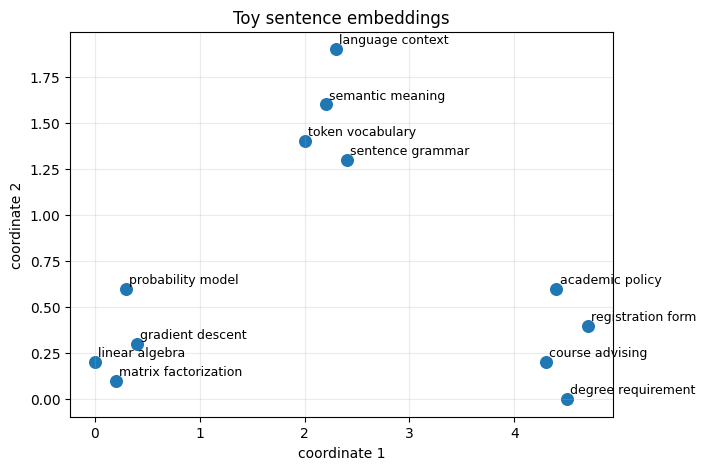

In [3]:
items = [
    "linear algebra",
    "matrix factorization",
    "gradient descent",
    "probability model",
    "token vocabulary",
    "semantic meaning",
    "sentence grammar",
    "language context",
    "course advising",
    "degree requirement",
    "registration form",
    "academic policy",
]

X = np.array([
    [0.0, 0.2],
    [0.2, 0.1],
    [0.4, 0.3],
    [0.3, 0.6],
    [2.0, 1.4],
    [2.2, 1.6],
    [2.4, 1.3],
    [2.3, 1.9],
    [4.3, 0.2],
    [4.5, 0.0],
    [4.7, 0.4],
    [4.4, 0.6],
], dtype=float)

plot_point_cloud(X, items, title="Toy sentence embeddings")

The visual point cloud suggests three semantic regions:

1. mathematical computation phrases,
2. language/NLP phrases,
3. advising/policy phrases.

Topology should not automatically be interpreted as semantics. But if embeddings are meaningful, semantic structure may appear as geometric or topological structure.

## 5. Distance matrices: Euclidean versus cosine

A finite metric space can be stored as a distance matrix. Euclidean distance uses absolute positions and lengths. Cosine distance uses directions after normalization.

For high-dimensional embedding models, cosine distance is often preferred because the direction of a vector can be more meaningful than its norm. But this is a modeling assumption, not a theorem.

In [4]:
D_euclid = euclidean_distances(X)
D_cosine = cosine_distances(X)

pd.DataFrame(D_euclid, index=items, columns=items).round(2)

,linear algebra,matrix factorization,gradient descent,probability model,token vocabulary,semantic meaning,sentence grammar,language context,course advising,degree requirement,registration form,academic policy
linear algebra,0.00,0.22,0.41,0.50,2.33,2.61,2.64,2.86,4.30,4.50,4.70,4.42
matrix factorization,0.22,0.00,0.28,0.51,2.22,2.50,2.51,2.77,4.10,4.30,4.51,4.23
gradient descent,0.41,0.28,0.00,0.32,1.94,2.22,2.24,2.48,3.90,4.11,4.30,4.01
probability model,0.50,0.51,0.32,0.00,1.88,2.15,2.21,2.39,4.02,4.24,4.40,4.10
token vocabulary,2.33,2.22,1.94,1.88,0.00,0.28,0.41,0.58,2.59,2.87,2.88,2.53
semantic meaning,2.61,2.50,2.22,2.15,0.28,0.00,0.36,0.32,2.52,2.80,2.77,2.42
sentence grammar,2.64,2.51,2.24,2.21,0.41,0.36,0.00,0.61,2.20,2.47,2.47,2.12
language context,2.86,2.77,2.48,2.39,0.58,0.32,0.61,0.00,2.62,2.91,2.83,2.47
course advising,4.30,4.10,3.90,4.02,2.59,2.52,2.20,2.62,0.00,0.28,0.45,0.41
degree requirement,4.50,4.30,4.11,4.24,2.87,2.80,2.47,2.91,0.28,0.00,0.45,0.61


In [5]:
pd.DataFrame(D_cosine, index=items, columns=items).round(2)

,linear algebra,matrix factorization,gradient descent,probability model,token vocabulary,semantic meaning,sentence grammar,language context,course advising,degree requirement,registration form,academic policy
linear algebra,0.00,0.55,0.40,0.11,0.43,0.41,0.52,0.36,0.95,1.00,0.92,0.86
matrix factorization,0.55,0.00,0.02,0.20,0.01,0.01,0.00,0.03,0.09,0.11,0.07,0.05
gradient descent,0.40,0.02,0.00,0.11,0.00,0.00,0.01,0.00,0.17,0.20,0.15,0.13
probability model,0.11,0.20,0.11,0.00,0.12,0.11,0.18,0.09,0.51,0.55,0.48,0.44
token vocabulary,0.43,0.01,0.00,0.12,0.00,0.00,0.01,0.00,0.16,0.18,0.14,0.11
semantic meaning,0.41,0.01,0.00,0.11,0.00,0.00,0.01,0.00,0.16,0.19,0.14,0.12
sentence grammar,0.52,0.00,0.01,0.18,0.01,0.01,0.00,0.02,0.10,0.12,0.08,0.06
language context,0.36,0.03,0.00,0.09,0.00,0.00,0.02,0.00,0.20,0.23,0.18,0.15
course advising,0.95,0.09,0.17,0.51,0.16,0.16,0.10,0.20,0.00,0.00,0.00,0.00
degree requirement,1.00,0.11,0.20,0.55,0.18,0.19,0.12,0.23,0.00,0.00,0.00,0.01


### Visualization of the distance matrix

The block structure in a heatmap often reveals clusters before we run any algorithm.

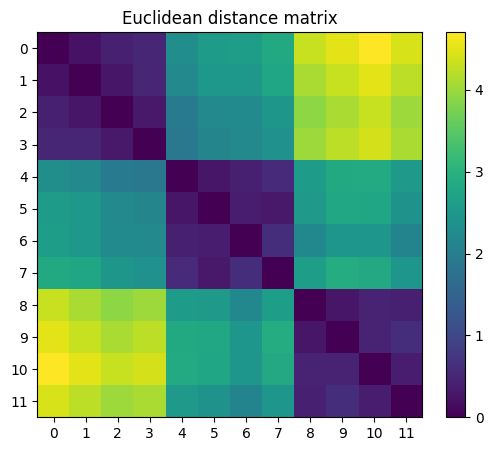

 0: linear algebra
 1: matrix factorization
 2: gradient descent
 3: probability model
 4: token vocabulary
 5: semantic meaning
 6: sentence grammar
 7: language context
 8: course advising
 9: degree requirement
10: registration form
11: academic policy


In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(D_euclid)
ax.set_xticks(range(len(items)))
ax.set_yticks(range(len(items)))
ax.set_xticklabels(range(len(items)))
ax.set_yticklabels(range(len(items)))
ax.set_title("Euclidean distance matrix")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

for k, name in enumerate(items):
    print(f"{k:2d}: {name}")

## 6. Neighborhood graphs and connected components

For a threshold $epsilon$, construct a graph with an edge between $x_i$ and $x_j$ when

$$
d(x_i,x_j) \le epsilon.
$$

As $epsilon$ increases, isolated points merge into connected components. This is the beginning of persistent homology in dimension 0.

In [7]:
for eps in [0.35, 0.55, 0.85, 1.50, 2.20]:
    edges = edges_at_threshold(D_euclid, eps)
    comps = connected_components(len(items), edges)
    print(f"epsilon={eps:4.2f}: edges={len(edges):2d}, components={len(comps):2d}")
    print([[items[i] for i in comp] for comp in comps])
    print()

epsilon=0.35: edges= 6, components= 6
[['linear algebra', 'matrix factorization', 'gradient descent', 'probability model'], ['token vocabulary', 'semantic meaning', 'language context'], ['sentence grammar'], ['course advising', 'degree requirement'], ['registration form'], ['academic policy']]

epsilon=0.55: edges=15, components= 3
[['linear algebra', 'matrix factorization', 'gradient descent', 'probability model'], ['token vocabulary', 'semantic meaning', 'sentence grammar', 'language context'], ['course advising', 'degree requirement', 'registration form', 'academic policy']]

epsilon=0.85: edges=18, components= 3
[['linear algebra', 'matrix factorization', 'gradient descent', 'probability model'], ['token vocabulary', 'semantic meaning', 'sentence grammar', 'language context'], ['course advising', 'degree requirement', 'registration form', 'academic policy']]

epsilon=1.50: edges=18, components= 3
[['linear algebra', 'matrix factorization', 'gradient descent', 'probability model'], 

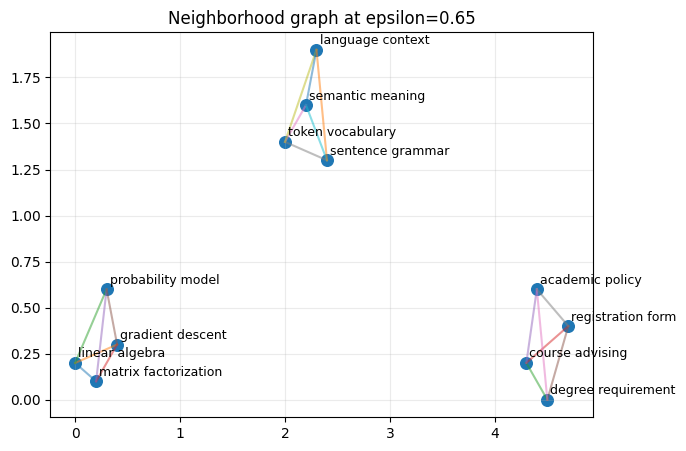

In [8]:
eps = 0.65
edges = edges_at_threshold(D_euclid, eps)
plot_graph_on_points(X, edges, labels=items, title=f"Neighborhood graph at epsilon={eps}")

A connected component is a topological summary of cluster structure. It ignores small metric changes inside a cluster and focuses on whether points are connected at a chosen scale.

But a single threshold can be misleading. Persistent homology studies all thresholds together.

## 7. Vietoris--Rips complexes

A graph sees pairwise connections. A simplicial complex adds higher-dimensional faces.

The Vietoris--Rips complex at scale $epsilon$ is built as follows:

- vertices are data points;
- an edge appears when two points are within distance $epsilon$;
- a triangle appears when all three pairwise edges are present;
- higher-dimensional simplices appear when all pairwise distances among their vertices are at most $epsilon$.

In this lab, we compute only vertices, edges, and triangles. This is enough to study $beta_0$ and $beta_1$ for small examples.

In [9]:
for eps in [0.35, 0.55, 0.85, 1.50, 2.20]:
    summary = betti_0_1(D_euclid, eps)
    print(summary)

{'eps': 0.35, 'vertices': 12, 'edges': 6, 'triangles': 0, 'rank_d1': 6, 'rank_d2': 0, 'beta0': 6, 'beta1': 0}
{'eps': 0.55, 'vertices': 12, 'edges': 15, 'triangles': 7, 'rank_d1': 9, 'rank_d2': 6, 'beta0': 3, 'beta1': 0}
{'eps': 0.85, 'vertices': 12, 'edges': 18, 'triangles': 12, 'rank_d1': 9, 'rank_d2': 9, 'beta0': 3, 'beta1': 0}
{'eps': 1.5, 'vertices': 12, 'edges': 18, 'triangles': 12, 'rank_d1': 9, 'rank_d2': 9, 'beta0': 3, 'beta1': 0}
{'eps': 2.2, 'vertices': 12, 'edges': 23, 'triangles': 15, 'rank_d1': 11, 'rank_d2': 12, 'beta0': 1, 'beta1': 0}


Interpretation:

- $beta_0$ counts connected components.
- $beta_1$ counts independent one-dimensional loops that are not filled by triangles.

In dense clusters, triangles fill many cycles, so $beta_1$ may be zero even when the graph contains cycles.

## 8. A loop example: sentence embeddings around a semantic cycle

To see $beta_1$ more clearly, we create a circular point cloud. In language applications, a loop might appear when a representation space organizes text along a cycle such as:

$$
question \to hint \to solution \to explanation \to reflection \to question.
$$

This is only a toy analogy. The purpose is to understand what a topological loop means computationally.

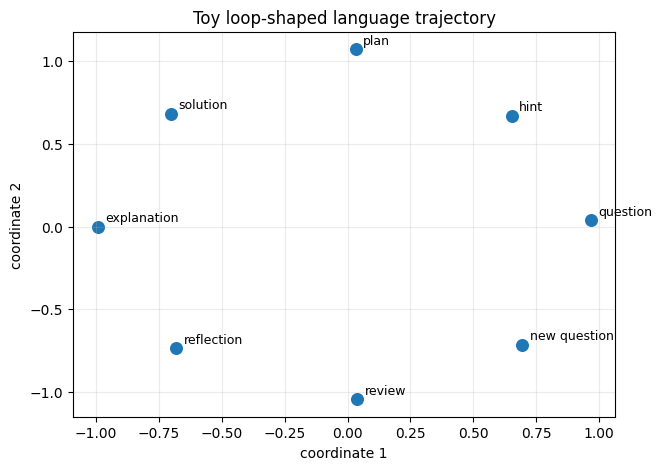

In [10]:
loop_labels = ["question", "hint", "plan", "solution", "explanation", "reflection", "review", "new question"]
angles = np.linspace(0, 2*np.pi, len(loop_labels), endpoint=False)
X_loop = np.c_[np.cos(angles), np.sin(angles)] + 0.04 * rng.normal(size=(len(loop_labels), 2))
D_loop = euclidean_distances(X_loop)

plot_point_cloud(X_loop, loop_labels, title="Toy loop-shaped language trajectory")

In [11]:
rows = []
for eps in np.linspace(0.45, 2.05, 9):
    rows.append(betti_0_1(D_loop, float(eps)))
loop_table = pd.DataFrame(rows)
loop_table[["eps", "edges", "triangles", "beta0", "beta1"]]

,eps,edges,triangles,beta0,beta1
0,0.45,0,0,8,0
1,0.65,0,0,8,0
2,0.85,8,0,1,1
3,1.05,8,0,1,1
4,1.25,8,0,1,1
5,1.45,14,6,1,1
6,1.65,16,8,1,1
7,1.85,21,21,1,0
8,2.05,27,50,1,0


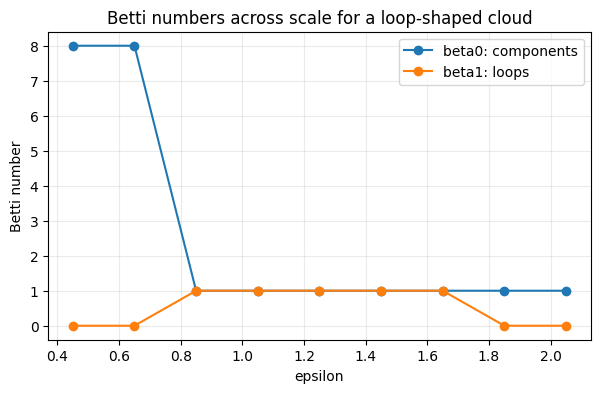

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loop_table["eps"], loop_table["beta0"], marker="o", label="beta0: components")
ax.plot(loop_table["eps"], loop_table["beta1"], marker="o", label="beta1: loops")
ax.set_xlabel("epsilon")
ax.set_ylabel("Betti number")
ax.set_title("Betti numbers across scale for a loop-shaped cloud")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

A loop often appears only for an intermediate range of $epsilon$:

- too small: the points are disconnected;
- medium: the cycle is connected but not filled;
- too large: triangles fill the cycle, so the hole disappears.

Persistence records the birth and death scales of such features.

## 9. Dimension-0 persistence with union-find

We now implement a simple $0$-dimensional persistence algorithm. Each point is born at scale $0$. When two components merge, the younger component dies at the edge length where the merge occurs.

This algorithm is closely related to Kruskal's algorithm for a minimum spanning tree.

In [13]:
def persistence_dim0(D):
    n = D.shape[0]
    candidate_edges = [(D[i, j], i, j) for i in range(n) for j in range(i+1, n)]
    candidate_edges.sort()
    uf = UnionFind(n)
    birth = {i: 0.0 for i in range(n)}
    intervals = []

    for dist, i, j in candidate_edges:
        ri, rj = uf.find(i), uf.find(j)
        if ri == rj:
            continue
        # In this simple version all births are zero, so choose one root to die.
        # For equal births, the larger root index dies for determinism.
        if ri < rj:
            survivor, dying = ri, rj
        else:
            survivor, dying = rj, ri
        intervals.append((birth[dying], float(dist), dying, survivor))
        uf.union(survivor, dying)
        new_root = uf.find(survivor)
        birth[new_root] = min(birth.get(survivor, 0.0), birth.get(dying, 0.0))

    # One final component persists forever.
    final_root = uf.find(0)
    intervals.append((0.0, np.inf, final_root, final_root))
    return intervals

intervals = persistence_dim0(D_euclid)
for birth, death, dying, survivor in intervals:
    death_str = "infinity" if np.isinf(death) else f"{death:.3f}"
    print(f"component represented by point {dying:2d} born at {birth:.1f}, dies at {death_str}")

component represented by point  1 born at 0.0, dies at 0.224
component represented by point  2 born at 0.0, dies at 0.283
component represented by point  9 born at 0.0, dies at 0.283
component represented by point  5 born at 0.0, dies at 0.283
component represented by point  7 born at 0.0, dies at 0.316
component represented by point  3 born at 0.0, dies at 0.316
component represented by point 11 born at 0.0, dies at 0.361
component represented by point  6 born at 0.0, dies at 0.361
component represented by point 10 born at 0.0, dies at 0.412
component represented by point  4 born at 0.0, dies at 1.879
component represented by point  8 born at 0.0, dies at 2.119
component represented by point  0 born at 0.0, dies at infinity


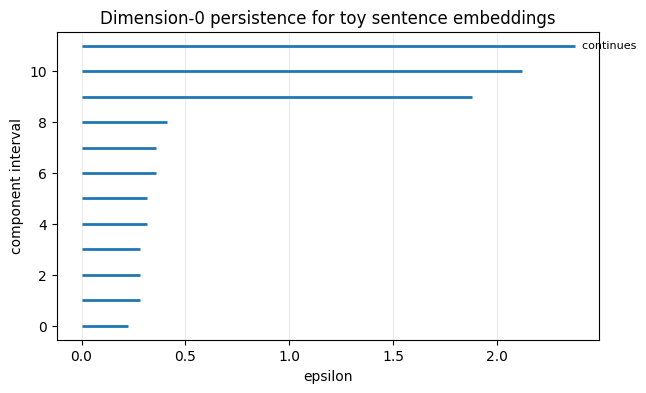

In [14]:
def plot_dim0_barcode(intervals, title="Dimension-0 persistence barcode"):
    finite_deaths = [d for _, d, _, _ in intervals if np.isfinite(d)]
    max_death = max(finite_deaths) if finite_deaths else 1.0
    fig, ax = plt.subplots(figsize=(7, 4))
    for k, (birth, death, dying, survivor) in enumerate(intervals):
        end = max_death * 1.12 if np.isinf(death) else death
        ax.hlines(k, birth, end, linewidth=2)
        if np.isinf(death):
            ax.text(end, k, "  continues", va="center", fontsize=8)
    ax.set_xlabel("epsilon")
    ax.set_ylabel("component interval")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)
    plt.show()

plot_dim0_barcode(intervals, title="Dimension-0 persistence for toy sentence embeddings")

Long component lifetimes suggest separated clusters. Short lifetimes suggest points that merge quickly with nearby neighbors.

For real language embeddings, this can help diagnose whether a representation separates topics, genres, roles, or prompt types.

## 10. A simple persistence curve for $beta_0$ and $beta_1$

Instead of a full persistence diagram, we can compute Betti numbers across a grid of scales. This is not as precise as full persistence, but it is easy to explain and useful for diagnostics.

In [15]:
def betti_curve(D, eps_values):
    return pd.DataFrame([betti_0_1(D, float(eps)) for eps in eps_values])

curve = betti_curve(D_euclid, np.linspace(0.2, 2.8, 14))
curve[["eps", "edges", "triangles", "beta0", "beta1"]]

,eps,edges,triangles,beta0,beta1
0,0.2,0,0,12,0
1,0.4,8,0,4,0
2,0.6,16,8,3,0
3,0.8,18,12,3,0
4,1.0,18,12,3,0
5,1.2,18,12,3,0
6,1.4,18,12,3,0
7,1.6,18,12,3,0
8,1.8,18,12,3,0
9,2.0,20,13,2,0


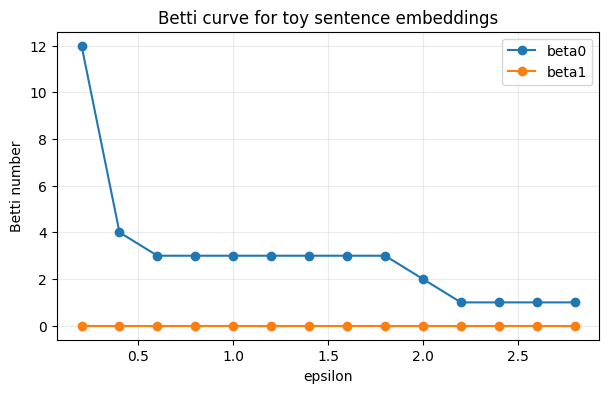

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["eps"], curve["beta0"], marker="o", label="beta0")
ax.plot(curve["eps"], curve["beta1"], marker="o", label="beta1")
ax.set_xlabel("epsilon")
ax.set_ylabel("Betti number")
ax.set_title("Betti curve for toy sentence embeddings")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

## 11. Local intrinsic dimension

Topology asks about shape. Geometry also asks about dimension.

A set of embeddings may live in $R^d$, but the local variation near a point may be close to a lower-dimensional subspace. A simple estimate is obtained by looking at the singular values of a local neighborhood.

For centered neighborhood matrix $Y$, let singular values be

$$
s_1 \ge s_2 \ge \cdots \ge 0.
$$

A simple effective dimension score is the participation ratio

$$
d_{eff}=\frac{(\sum_k s_k^2)^2}{\sum_k s_k^4}.
$$

This value is near 1 when most variation lies on a line, near 2 for a plane, and larger for more spread-out variation.

In [17]:
def local_effective_dimension(X, k=4):
    X = np.asarray(X, dtype=float)
    D = euclidean_distances(X)
    dims = []
    for i in range(len(X)):
        nn = np.argsort(D[i])[1:k+1]
        Y = X[nn] - X[nn].mean(axis=0, keepdims=True)
        s = np.linalg.svd(Y, compute_uv=False)
        power = s**2
        if np.sum(power**2) == 0:
            dims.append(0.0)
        else:
            dims.append((np.sum(power)**2) / np.sum(power**2))
    return np.array(dims)

local_dim = local_effective_dimension(X, k=4)
pd.DataFrame({"item": items, "local_effective_dimension": local_dim}).round(3)

,item,local_effective_dimension
0,linear algebra,1.050
1,matrix factorization,1.030
2,gradient descent,1.039
3,probability model,1.011
4,token vocabulary,1.091
5,semantic meaning,1.095
6,sentence grammar,1.074
7,language context,1.040
8,course advising,1.072
9,degree requirement,1.049


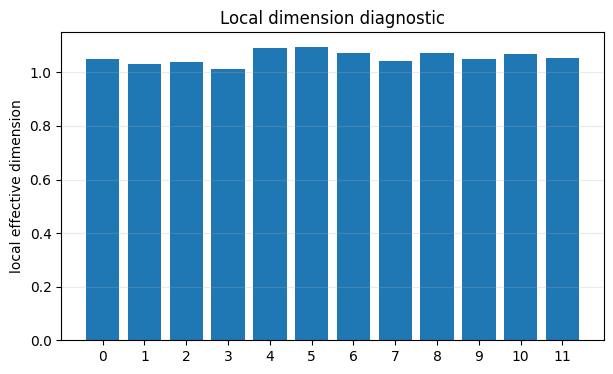

 0: linear algebra
 1: matrix factorization
 2: gradient descent
 3: probability model
 4: token vocabulary
 5: semantic meaning
 6: sentence grammar
 7: language context
 8: course advising
 9: degree requirement
10: registration form
11: academic policy


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(items)), local_dim)
ax.set_xticks(range(len(items)))
ax.set_xticklabels(range(len(items)))
ax.set_ylabel("local effective dimension")
ax.set_title("Local dimension diagnostic")
ax.grid(True, axis="y", alpha=0.25)
plt.show()

for k, name in enumerate(items):
    print(f"{k:2d}: {name}")

Local dimension is a diagnostic, not a final interpretation. High or low local dimension may reflect meaningful semantic variation, noise, preprocessing choices, anisotropy, or sample-size effects.

## 12. Mapper-style summary

Mapper is a topological method that summarizes a point cloud using:

1. a filter function, such as a principal component, confidence score, or document length;
2. overlapping intervals covering the range of the filter;
3. clustering inside each interval;
4. a graph connecting clusters that share points.

Here we implement a very small Mapper-style construction using the first principal coordinate as the filter. We use connected components at a local distance threshold as clusters.

In [19]:
def first_principal_coordinate(X):
    Y = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Y, full_matrices=False)
    return Y @ Vt[0]


def simple_mapper(X, labels, n_intervals=4, overlap=0.35, local_eps=0.55):
    z = first_principal_coordinate(X)
    z_min, z_max = z.min(), z.max()
    width = (z_max - z_min) / (n_intervals - (n_intervals - 1) * overlap)
    step = width * (1 - overlap)
    intervals = [(z_min + a*step, z_min + a*step + width) for a in range(n_intervals)]

    mapper_nodes = []
    memberships = []
    for interval_id, (lo, hi) in enumerate(intervals):
        idx = np.where((z >= lo) & (z <= hi))[0]
        if len(idx) == 0:
            continue
        D_local = euclidean_distances(X[idx])
        edges_local = edges_at_threshold(D_local, local_eps)
        comps = connected_components(len(idx), edges_local)
        for comp in comps:
            original = sorted(idx[c] for c in comp)
            node_name = f"I{interval_id}_C{len(mapper_nodes)}"
            mapper_nodes.append(node_name)
            memberships.append(original)

    mapper_edges = []
    for a, b in combinations(range(len(memberships)), 2):
        if set(memberships[a]) & set(memberships[b]):
            mapper_edges.append((a, b))

    return z, intervals, mapper_nodes, memberships, mapper_edges

z, intervals, m_nodes, memberships, m_edges = simple_mapper(X, items)

print("Filter coordinate:")
for i, (name, value) in enumerate(zip(items, z)):
    print(f"{i:2d} {value:7.3f}  {name}")

print("\nMapper intervals:")
for i, interval in enumerate(intervals):
    print(i, tuple(round(v, 3) for v in interval))

print("\nMapper nodes and memberships:")
for node_id, members in enumerate(memberships):
    print(f"{node_id}: {[items[i] for i in members]}")

print("\nMapper edges:", m_edges)

Filter coordinate:
 0  -2.303  linear algebra
 1  -2.102  matrix factorization
 2  -1.904  gradient descent
 3  -2.007  probability model
 4  -0.316  token vocabulary
 5  -0.118  semantic meaning
 6   0.085  sentence grammar
 7  -0.021  language context
 8   1.997  course advising
 9   2.199  degree requirement
10   2.395  registration form
11   2.093  academic policy

Mapper intervals:
0 (np.float64(-2.303), np.float64(-0.71))
1 (np.float64(-1.268), np.float64(0.325))
2 (np.float64(-0.233), np.float64(1.36))
3 (np.float64(0.803), np.float64(2.395))

Mapper nodes and memberships:
0: ['linear algebra', 'matrix factorization', 'gradient descent', 'probability model']
1: ['token vocabulary', 'semantic meaning', 'sentence grammar', 'language context']
2: ['semantic meaning', 'sentence grammar', 'language context']
3: ['course advising', 'degree requirement', 'registration form', 'academic policy']

Mapper edges: [(1, 2)]


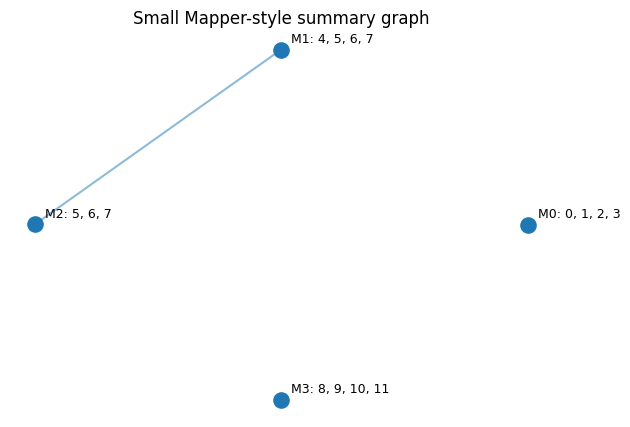

Index key:
 0: linear algebra
 1: matrix factorization
 2: gradient descent
 3: probability model
 4: token vocabulary
 5: semantic meaning
 6: sentence grammar
 7: language context
 8: course advising
 9: degree requirement
10: registration form
11: academic policy


In [20]:
def plot_mapper(memberships, mapper_edges, labels):
    n = len(memberships)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = np.c_[np.cos(angles), np.sin(angles)]
    fig, ax = plt.subplots(figsize=(7, 5))
    for a, b in mapper_edges:
        ax.plot([pos[a,0], pos[b,0]], [pos[a,1], pos[b,1]], alpha=0.5)
    ax.scatter(pos[:,0], pos[:,1], s=120)
    for i, members in enumerate(memberships):
        member_text = ", ".join(str(m) for m in members)
        ax.text(pos[i,0] + 0.04, pos[i,1] + 0.04, f"M{i}: {member_text}", fontsize=9)
    ax.set_title("Small Mapper-style summary graph")
    ax.axis("off")
    plt.show()

plot_mapper(memberships, m_edges, items)

print("Index key:")
for i, name in enumerate(items):
    print(f"{i:2d}: {name}")

Mapper can reveal branching or chain-like organization in a representation. But it depends on choices: filter function, number of intervals, overlap, and local clustering threshold. Always report these choices.

## 13. Topology as a representation diagnostic

Now we compare three synthetic representation spaces:

1. clustered points,
2. loop-shaped points,
3. nearly line-shaped points.

All three are point clouds, but they have different geometric and topological signatures.

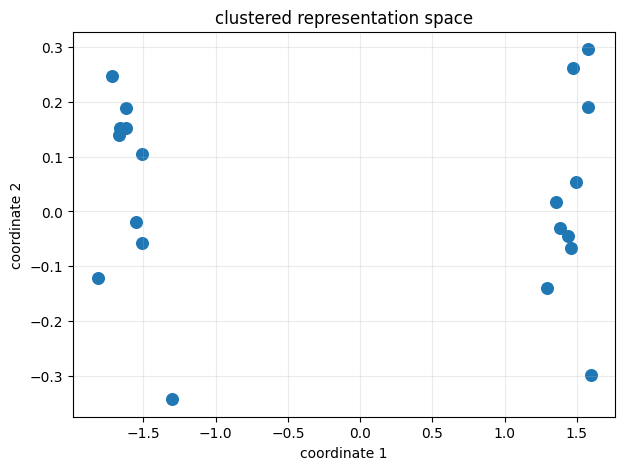

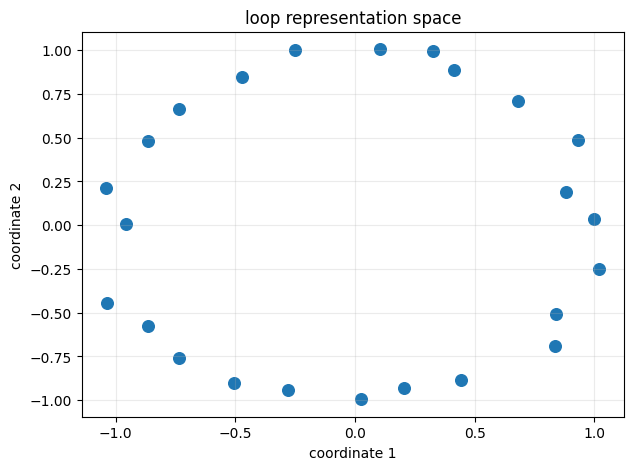

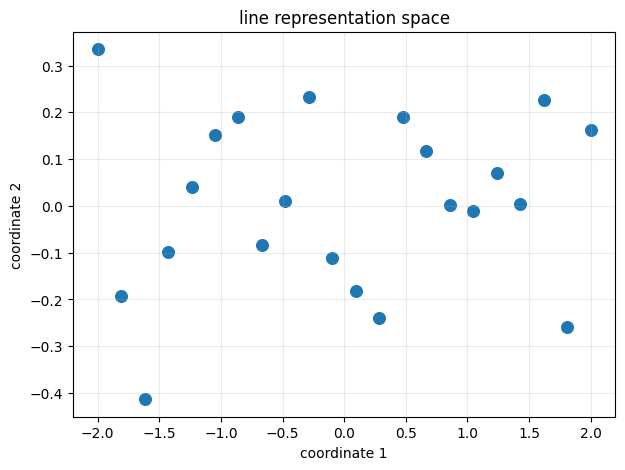

In [21]:
# Clustered cloud
cluster_a = rng.normal(loc=(-1.5, 0.0), scale=0.18, size=(10, 2))
cluster_b = rng.normal(loc=(1.5, 0.0), scale=0.18, size=(10, 2))
clustered = np.vstack([cluster_a, cluster_b])

# Loop-shaped cloud
angles = np.linspace(0, 2*np.pi, 24, endpoint=False)
loop = np.c_[np.cos(angles), np.sin(angles)] + 0.05 * rng.normal(size=(24, 2))

# Line-shaped cloud
xline = np.linspace(-2, 2, 22)
line = np.c_[xline, 0.15 * rng.normal(size=len(xline))]

clouds = {"clustered": clustered, "loop": loop, "line": line}

for name, cloud in clouds.items():
    plot_point_cloud(cloud, title=f"{name} representation space", annotate=False)

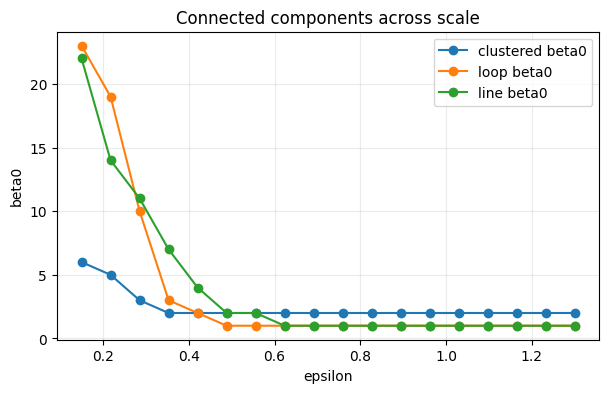

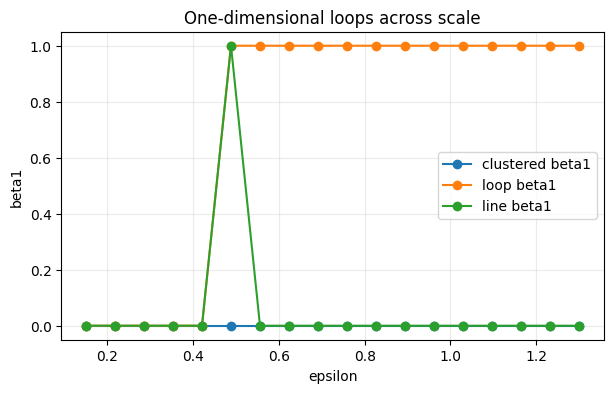

In [22]:
eps_values = np.linspace(0.15, 1.30, 18)
summary_tables = {}
for name, cloud in clouds.items():
    table = betti_curve(euclidean_distances(cloud), eps_values)
    summary_tables[name] = table

fig, ax = plt.subplots(figsize=(7, 4))
for name, table in summary_tables.items():
    ax.plot(table["eps"], table["beta0"], marker="o", label=f"{name} beta0")
ax.set_xlabel("epsilon")
ax.set_ylabel("beta0")
ax.set_title("Connected components across scale")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for name, table in summary_tables.items():
    ax.plot(table["eps"], table["beta1"], marker="o", label=f"{name} beta1")
ax.set_xlabel("epsilon")
ax.set_ylabel("beta1")
ax.set_title("One-dimensional loops across scale")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

Possible interpretations:

- A clustered space may show persistent $beta_0$ structure.
- A loop-shaped space may show nonzero $beta_1$ over an interval of scales.
- A line-shaped space may have many short-lived components but little loop structure.

In real NLP, these patterns should be treated as diagnostic evidence, not automatic proof of semantic structure.

## 14. Stability experiment: adding noise

Topological summaries are useful partly because persistent features are more stable than tiny local fluctuations. We test this by adding noise to the loop cloud and comparing Betti curves.

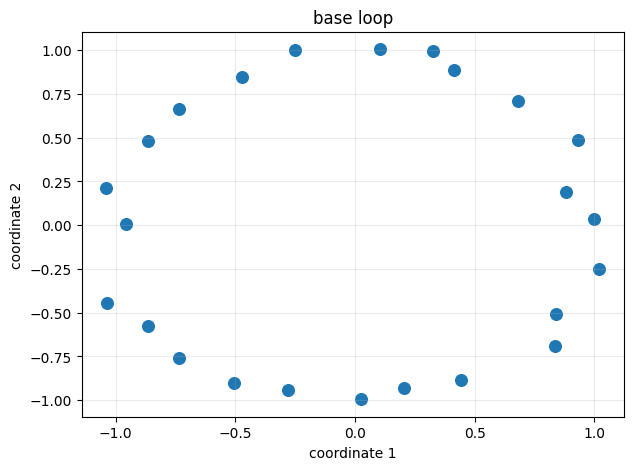

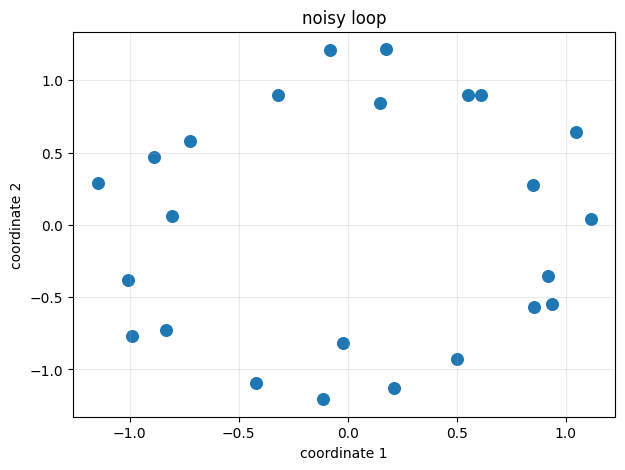

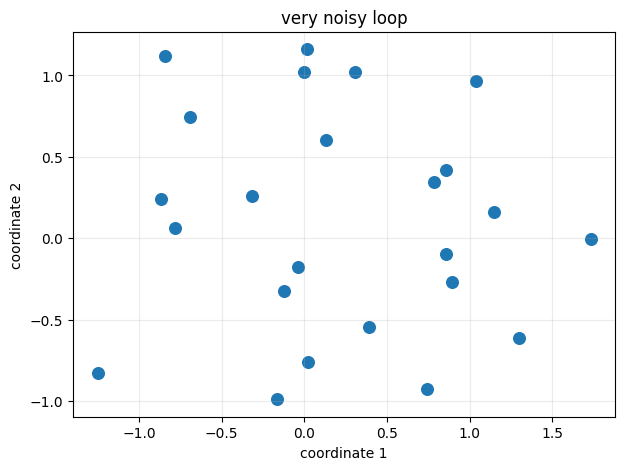

In [23]:
base_loop = loop.copy()
noisy_loop = base_loop + 0.12 * rng.normal(size=base_loop.shape)
very_noisy_loop = base_loop + 0.35 * rng.normal(size=base_loop.shape)

loop_variants = {
    "base loop": base_loop,
    "noisy loop": noisy_loop,
    "very noisy loop": very_noisy_loop,
}

for name, cloud in loop_variants.items():
    plot_point_cloud(cloud, title=name, annotate=False)

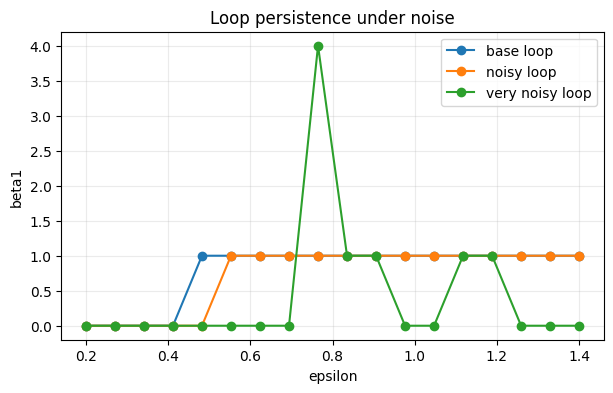

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, cloud in loop_variants.items():
    table = betti_curve(euclidean_distances(cloud), np.linspace(0.2, 1.4, 18))
    ax.plot(table["eps"], table["beta1"], marker="o", label=name)
ax.set_xlabel("epsilon")
ax.set_ylabel("beta1")
ax.set_title("Loop persistence under noise")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

The exact curve changes under noise, but a robust loop-like feature may survive over a range of scales. When a feature appears only at one tiny scale, it is less convincing.

## 15. Responsible interpretation checklist

When using topology for language representations, ask:

1. **What are the objects?** Words, sentences, documents, prompts, hidden states, or retrieved chunks?
2. **What distance is used?** Euclidean, cosine, edit distance, learned distance, or task-specific dissimilarity?
3. **What preprocessing was done?** Centering, normalization, dimensionality reduction, filtering?
4. **What scale range is examined?** Does the feature persist or appear only briefly?
5. **What is the null baseline?** Random embeddings, shuffled labels, or simple bag-of-words features?
6. **What is the semantic hypothesis?** Does the topology answer a concrete NLP question?
7. **What are the limitations?** Sample size, embedding bias, anisotropy, density variation, and projection artifacts.

Topology can reveal structure. It does not automatically explain that structure.

## 16. AI-assisted learning prompts

Use an AI assistant as a critic, not as a substitute for computation. Suggested prompts:

1. *I computed $beta_0$ and $beta_1$ for a sentence-embedding point cloud. Help me list possible non-semantic reasons these values could arise.*
2. *Explain the difference between a neighborhood graph and a Vietoris--Rips complex using a small NLP example.*
3. *Given this distance matrix and threshold, check whether my list of edges and triangles is correct.*
4. *Help me design a null baseline for testing whether the topology of my embeddings is meaningful.*
5. *Critique this claim: The embedding space has a loop, therefore the language task is cyclic.*

After using an assistant, verify every mathematical and computational claim yourself.

## 17. Exercises

### Exercise 1: Cosine versus Euclidean topology

Compute Betti curves for the toy sentence embeddings using cosine distance instead of Euclidean distance. Compare the results. Which distance makes more sense for these toy coordinates?

### Exercise 2: Change the threshold

Choose three values of $epsilon$ for the toy sentence embeddings. For each one, list:

- number of edges,
- number of triangles,
- $beta_0$,
- $beta_1$,
- a short interpretation.

### Exercise 3: Make your own loop

Create 10 short labels describing a cyclic process in language learning or problem solving. Put them around a circle, add small noise, and compute the Betti curve.

### Exercise 4: Null baseline

Randomly permute the coordinates of the toy sentence embeddings or generate Gaussian random embeddings with the same number of points. Compare their Betti curves to the original.

### Exercise 5: Mapper sensitivity

Change the number of Mapper intervals, overlap, and local threshold. Which choices make the summary graph stable? Which choices make it unstable?

## 18. Mini-project: topology of course-advising language embeddings

Create a small corpus of 20 to 40 short advising-related sentences, such as:

- transfer credit questions,
- course prerequisite questions,
- degree requirement questions,
- co-op planning questions,
- registration policy questions.

Then:

1. Build simple sentence vectors using either hand-designed coordinates, TF-IDF vectors, or embeddings from a model available in your environment.
2. Compute a distance matrix.
3. Build neighborhood graphs across several thresholds.
4. Compute $beta_0$ and $beta_1$ curves.
5. Estimate local effective dimension.
6. Build a Mapper-style summary using a filter such as first principal coordinate, sentence length, or policy-related keyword count.
7. Write a short report answering:
   - What structure appears?
   - Is the structure stable across thresholds?
   - What semantic interpretation is plausible?
   - What alternative explanations are possible?

The strongest reports will include a null baseline and a careful limitations paragraph.

## 19. Summary

In this lab, we studied language representations as finite metric spaces. We built distance matrices, neighborhood graphs, Vietoris--Rips complexes, Betti-number curves, dimension-0 persistence barcodes, local dimension diagnostics, and a small Mapper-style graph.

The main lesson is:

> Topology gives multiscale summaries of the shape of representation spaces. These summaries can help diagnose NLP models, but they must be interpreted with care.

You are now ready to connect topology with the final chapter's discussion of responsible language technology.